# Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

# Loading Dataset

In [4]:
data = pd.read_csv("creditcard.csv")
data.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
print(data.describe())
print(data.shape)

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

#Describing the Data

#Imbalance in the data

In [7]:
fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]
outlierFraction = len(fraud)/float(len(valid))
print(outlierFraction)
print('Fraud Cases: {}'.format(len(data[data['Class'] == 1])))
print('Valid Transactions: {}'.format(len(data[data['Class'] == 0])))

0.0017304750013189597
Fraud Cases: 492
Valid Transactions: 284315


#Print the amount details for Fraudulent Transaction

In [8]:
print("Amount details of the fraudulent transaction")
fraud.Amount.describe()

Amount details of the fraudulent transaction


count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

# Print the amount details for Normal Transaction

In [9]:
print("details of valid transaction")
valid.Amount.describe()

details of valid transaction


count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

### Plotting the Correlation Matrix

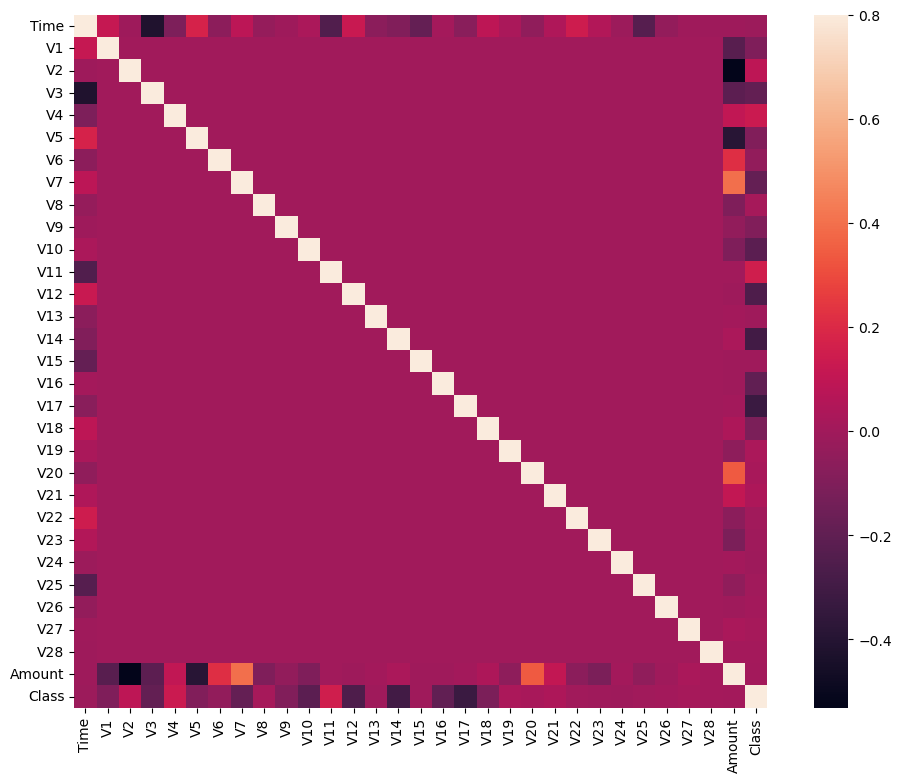

In [10]:
corrmat = data.corr()
fig = plt.figure(figsize = (12, 9))
sns.heatmap(corrmat, vmax = .8, square = True)
plt.show()

#### Separating the X and the Y values
#### Training and Testing Data Bifurcation
#### Building random forest model


In [11]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Split
X = data.drop('Class', axis=1)
Y = data['Class']

xTrain, xTest, yTrain, yTest = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Base model
rfc = RandomForestClassifier(class_weight='balanced', random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Grid Search
grid = GridSearchCV(
    estimator=rfc,
    param_grid=param_grid,
    scoring='recall',   # IMPORTANT
    cv=3,
    n_jobs=-1
)

# Train (ONLY on training data)
grid.fit(xTrain, yTrain)

# Best model
best_model = grid.best_estimator_

# Prediction
yPred = best_model.predict(xTest)

# Building all kinds of evaluating parameters

In [12]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Probabilities
yProb = best_model.predict_proba(xTest)[:, 1]

# Custom threshold
threshold = 0.3
yPred = (yProb > threshold).astype(int)

print("ROC-AUC:", roc_auc_score(yTest, yProb))
print("PR-AUC:", average_precision_score(yTest, yProb))

print("\nConfusion Matrix:")
print(confusion_matrix(yTest, yPred))

print("\nClassification Report:")
print(classification_report(yTest, yPred))

ROC-AUC: 0.9845373996531646
PR-AUC: 0.8421179552377278

Confusion Matrix:
[[56815    49]
 [   11    87]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.64      0.89      0.74        98

    accuracy                           1.00     56962
   macro avg       0.82      0.94      0.87     56962
weighted avg       1.00      1.00      1.00     56962



#Visualizing the Confusion Matrix

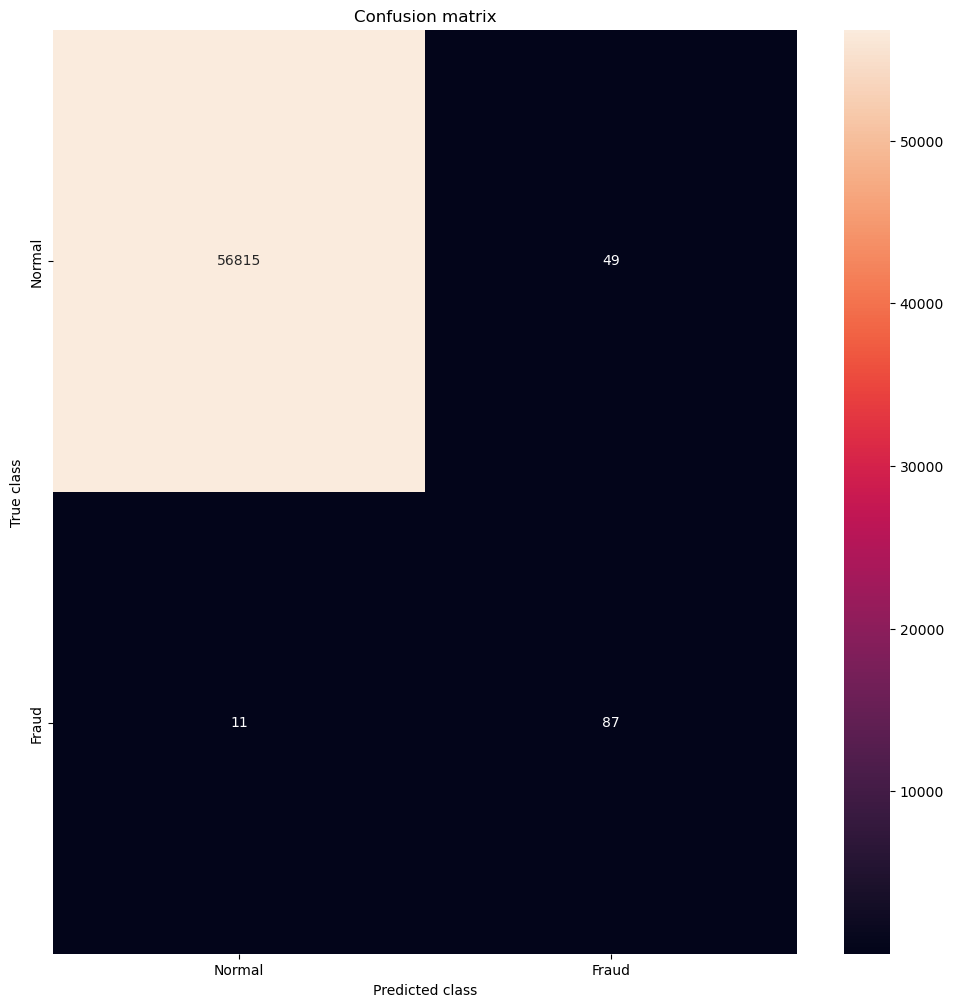

In [13]:
# printing the confusion matrix
LABELS = ['Normal', 'Fraud']
conf_matrix = confusion_matrix(yTest, yPred)
plt.figure(figsize =(12, 12))
sns.heatmap(conf_matrix, xticklabels = LABELS,
            yticklabels = LABELS, annot = True, fmt ="d");
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

In [14]:
import joblib

joblib.dump(best_model, "Credit_card_fraud_model.pkl")

['Credit_card_fraud_model.pkl']

In [ ]:
import joblib
import numpy as np
import pandas as pd

# Load model
model = joblib.load("Credit_card_fraud_model.pkl")

# Example: user input (must match dataset format)
# Format: Time, V1, V2, ..., V28, Amount
user_input = [27,-0.246045949,0.473266903,1.695737554,0.262411488,-0.010866414,-0.610835935,0.793936546,-0.247252831,0.138879114,-0.401007068,-0.812050382,-0.183524462,-0.630112887,-0.286217451,-0.337046324,-0.428105474,-0.030602108,-0.504568166,0.355180278,0.045721127,-0.194599935,-0.335132726,-0.078179606,0.392783892,-0.031157147,0.198036799,-0.175347301,-0.203616156,30.49]  

# Convert to numpy
user_input = np.array(user_input).reshape(1, -1)


columns = X.columns  

user_input_df = pd.DataFrame(user_input, columns=columns)

# Prediction
prediction = model.predict(user_input_df)

if prediction[0] == 1:
    print("⚠️ Fraud Transaction")
else:
    print("✅ Valid Transaction")

✅ Normal Transaction
